# Lab 4: CNN for Image Classification - Apple Disease Dataset
**Using `tf.data.AUTOTUNE` for Data Pipeline Optimization**

This notebook implements a Convolutional Neural Network (CNN) to classify apple leaf images into 4 categories:
- Apple Scab
- Black Rot
- Cedar Apple Rust
- Healthy

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os


print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. Configuration

In [2]:
TRAIN_DIR = 'datasets/train'
TEST_DIR  = 'datasets/test'

IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 32
EPOCHS      = 10
NUM_CLASSES = 4

# AUTOTUNE lets TensorFlow dynamically tune the buffer size at runtime
AUTOTUNE = tf.data.AUTOTUNE

print(f"Image Size : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epochs     : {EPOCHS}")
print(f"AUTOTUNE   : {AUTOTUNE}")

Image Size : 128x128
Batch Size : 32
Epochs     : 10
AUTOTUNE   : -1


## 3. Load Dataset

In [3]:
# Training set (80% of train directory)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training'
)

# Validation set (20% of train directory)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

# Test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")

Found 7771 files belonging to 4 classes.
Using 6217 files for training.
Found 7771 files belonging to 4 classes.
Using 1554 files for validation.
Found 1943 files belonging to 4 classes.
Classes: ['apple_scab', 'black_rot', 'cedar_apple_rust', 'healthy']


## 4. Apply AUTOTUNE - Data Pipeline Optimization

The `tf.data.AUTOTUNE` function dynamically tunes the buffer size for prefetching at runtime.
This allows TensorFlow to automatically decide the optimal number of elements to prefetch
based on available CPU and memory, improving data loading performance.

**Pipeline:** `cache()` -> `shuffle()` -> `prefetch(AUTOTUNE)`

In [4]:
def configure_for_performance(ds, shuffle=False):
    """Apply caching, shuffling, and prefetching with AUTOTUNE."""
    ds = ds.cache()                          # Cache dataset in memory after first epoch
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)    # Shuffle with buffer
    ds = ds.prefetch(buffer_size=AUTOTUNE)   # AUTOTUNE: TF decides optimal prefetch buffer
    return ds

train_ds = configure_for_performance(train_ds, shuffle=True)
val_ds   = configure_for_performance(val_ds)
test_ds  = configure_for_performance(test_ds)

print("[OK] AUTOTUNE applied: cache() + prefetch(AUTOTUNE) for optimal pipeline performance")

[OK] AUTOTUNE applied: cache() + prefetch(AUTOTUNE) for optimal pipeline performance


## 5. Visualize Sample Images

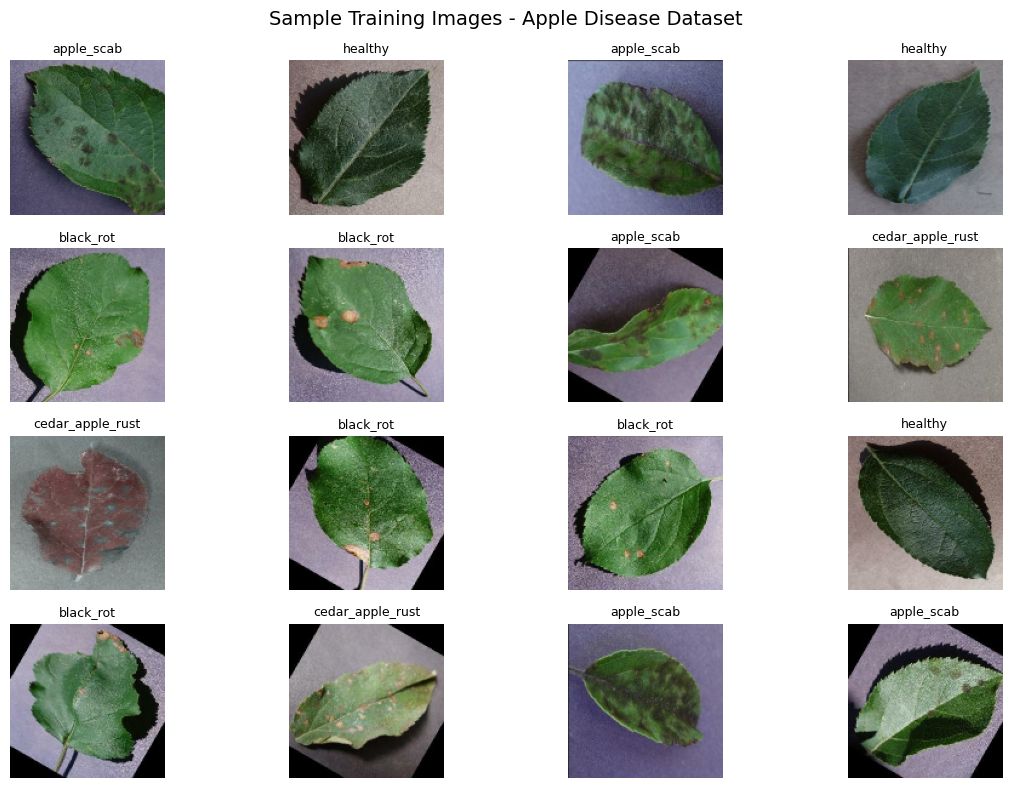

In [5]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(16, len(images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Images - Apple Disease Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Data Augmentation Layer

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

print("Data augmentation layers defined.")

Data augmentation layers defined.


## 7. Build CNN Model

In [7]:
model = models.Sequential([
    # Input and Normalization
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Rescaling(1.0 / 255),           # Normalize pixel values to [0, 1]
    data_augmentation,                      # Apply data augmentation

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')   # 4-class output
])

model.summary()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,618,308 (17.62 MB)

 Trainable params: 4,617,348 (17.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Compile the Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("[OK] Model compiled with Adam optimizer and Sparse Categorical Crossentropy loss")

[OK] Model compiled with Adam optimizer and Sparse Categorical Crossentropy loss


## 9. Train the Model

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.7024 - loss: 1.6173 - val_accuracy: 0.2362 - val_loss: 48.6422
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.7857 - loss: 0.7281 - val_accuracy: 0.3713 - val_loss: 5.0199
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.8359 - loss: 0.5778 - val_accuracy: 0.4569 - val_loss: 2.4836
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 202s 930ms/step - accuracy: 0.8776 - loss: 0.4336 - val_accuracy: 0.8848 - val_loss: 0.3899
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8966 - loss: 0.3612 - val_accuracy: 0.2619 - val_loss: 5.9274
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.9223 - loss: 0.2730 - val_accuracy: 0.8468 - val_loss: 0.5395
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9310 - loss: 0.2261 - val_accuracy: 0.7831 - val_loss: 0.8406
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 153s 779ms/step - accuracy: 0.9413 - loss: 0.2012 - v

## 10. Plot Training History

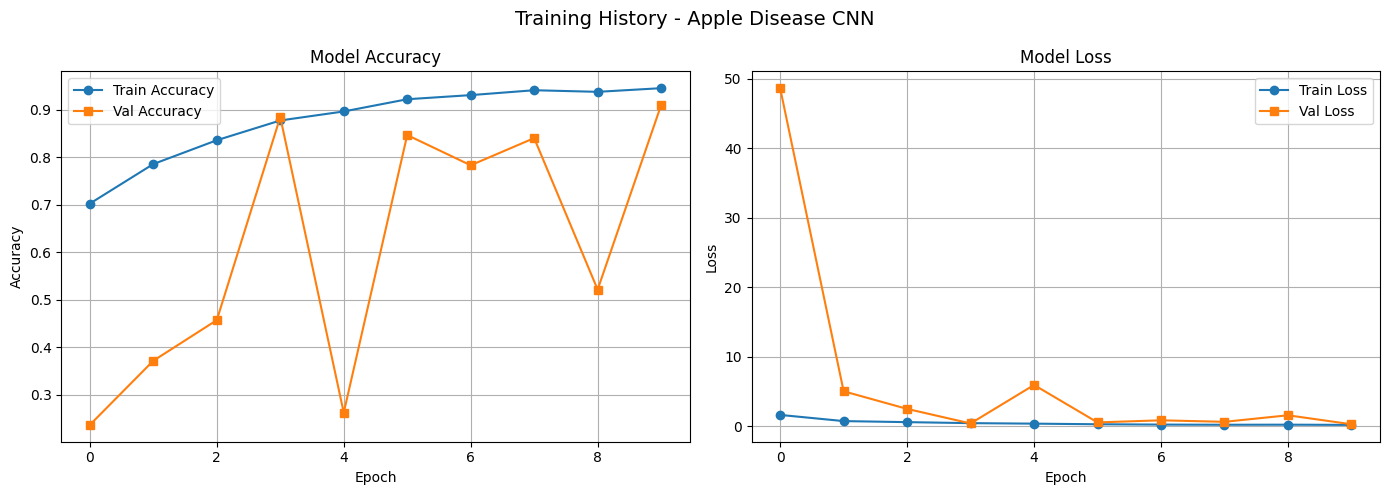

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training History - Apple Disease CNN', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Evaluate on Test Set

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9032 - loss: 0.2745

Test Loss:     0.2745
Test Accuracy: 0.9032 (90.32%)


## 12. Classification Report

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect all predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                  precision    recall  f1-score   support

      apple_scab       0.75      0.99      0.86       504
       black_rot       1.00      0.75      0.86       497
cedar_apple_rust       1.00      0.98      0.99       440
         healthy       0.96      0.90      0.92       502

        accuracy                           0.90      1943
       macro avg       0.93      0.91      0.91      1943
    weighted avg       0.92      0.90      0.90      1943



## 13. Confusion Matrix

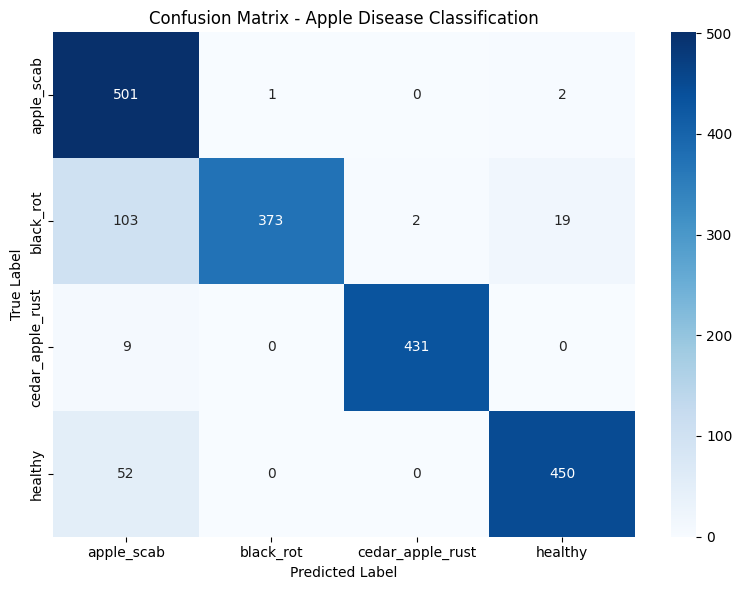

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Apple Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 14. Predict on Sample Test Images

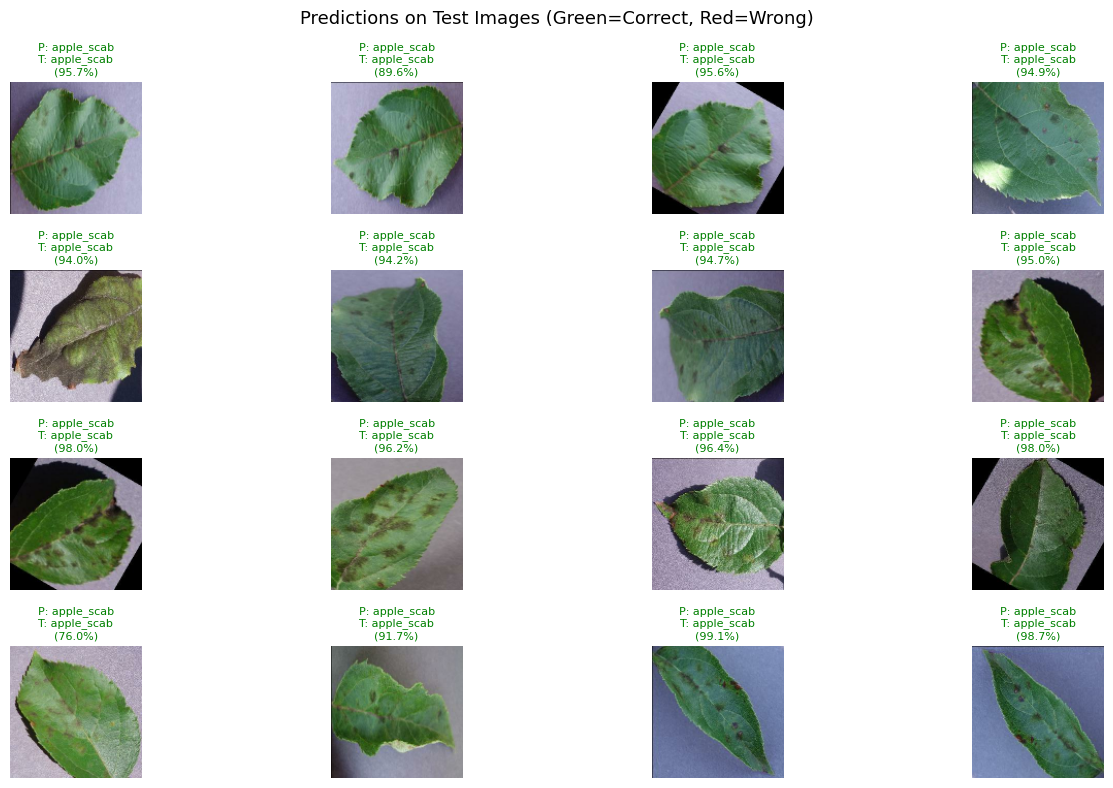

In [14]:
plt.figure(figsize=(14, 8))
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    for i in range(min(16, len(images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i]]
        confidence = np.max(predictions[i]) * 100
        color = 'green' if pred_class == true_class else 'red'
        plt.title(f"P: {pred_class}\nT: {true_class}\n({confidence:.1f}%)",
                  fontsize=8, color=color)
        plt.axis("off")

plt.suptitle("Predictions on Test Images (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## 15. Save the Model

In [15]:
model.save('apple_disease_cnn_model.h5')
print("[OK] Model saved as 'apple_disease_cnn_model.h5'")

print("\n" + "=" * 60)
print("  Lab 4 Complete: CNN for Apple Disease Classification")
print(f"  Final Test Accuracy: {test_accuracy*100:.2f}%")
print("  AUTOTUNE used for: cache(), prefetch(), data pipeline")
print("=" * 60)

[OK] Model saved as 'apple_disease_cnn_model.h5'

  Lab 4 Complete: CNN for Apple Disease Classification
  Final Test Accuracy: 90.32%
  AUTOTUNE used for: cache(), prefetch(), data pipeline
